<a href="https://colab.research.google.com/github/Jayrikers/Agricrop-chatbot/blob/main/GCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)


In [17]:
client = pd.read_csv('Client.csv')
record = pd.read_csv('Record.csv')

Merge the datasets using Customer_ID.

In [18]:
merged = client.merge(record, on="Customer_ID")

Verify the merge wokrd

In [19]:
merged.shape

(100000, 100)

In [26]:
missing_count = merged.isnull().sum()

missing_pct = (merged.isnull().sum() / len(merged)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_pct
})

missing_summary = missing_summary.sort_values(
    by='Missing Percentage',
    ascending=False
)

print(missing_summary.head(20))

                  Missing Count  Missing Percentage
numbcars                  49366              49.366
dwllsize                  38308              38.308
HHstatin                  37923              37.923
ownrent                   33706              33.706
dwlltype                  31909              31.909
lor                       30190              30.190
income                    25436              25.436
adults                    23019              23.019
infobase                  22079              22.079
hnd_webcap                10189              10.189
prizm_social_one           7388               7.388
avg6rev                    2839               2.839
avg6qty                    2839               2.839
avg6mou                    2839               2.839
ethnic                     1732               1.732
forgntvl                   1732               1.732
marital                    1732               1.732
kid0_2                     1732               1.732
rv          

In [28]:
merged['Customer_ID'].duplicated().sum()


np.int64(0)

In [23]:
df['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.50438
1,0.49562


How many customers churned?

In [25]:
merged['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.50438
1,0.49562


In [29]:
merged['churn'].isnull().sum()

np.int64(0)

In [32]:
missing_pct = (merged.isnull().mean() * 100).sort_values(ascending=False)

missing_pct = missing_pct[missing_pct > 0]

missing_pct.head(10)

,0
numbcars,49.366
dwllsize,38.308
HHstatin,37.923
ownrent,33.706
dwlltype,31.909
lor,30.190
income,25.436
adults,23.019
infobase,22.079
hnd_webcap,10.189


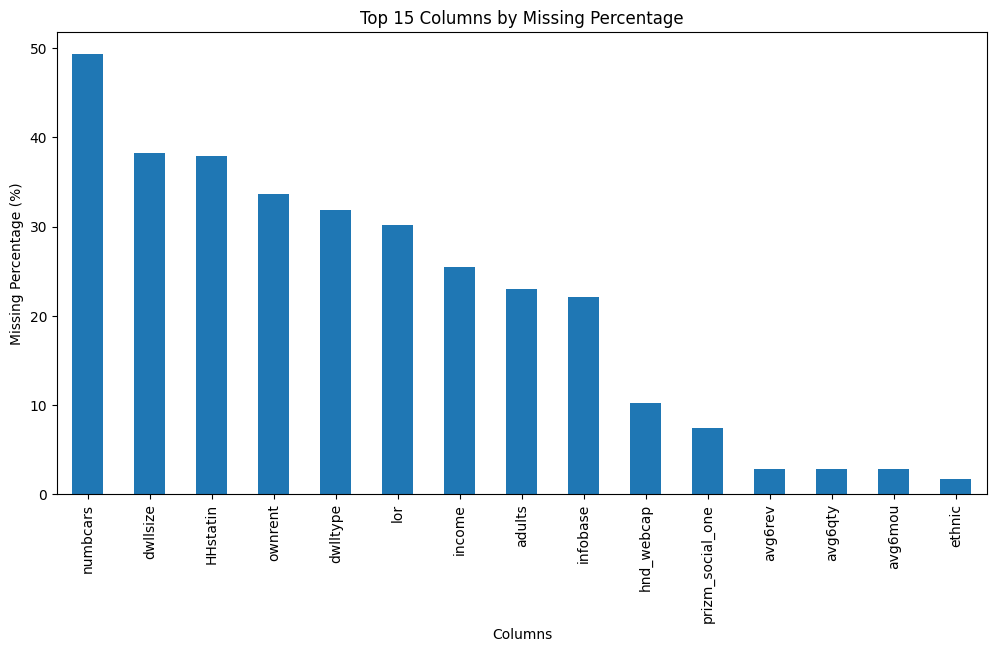

In [33]:
import matplotlib.pyplot as plt

missing_pct.head(15).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 15 Columns by Missing Percentage')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.xticks(rotation=90)
plt.show()


In [34]:
#cols_to_drop = ['Customer_ID', 'numbcars']
merged = merged.drop(columns=['Customer_ID', 'numbcars'])

In [35]:
num_cols = merged.select_dtypes(include=['int64', 'float64']).columns

cat_cols = merged.select_dtypes(include='object').columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 77
Categorical columns: 21


In [39]:

merged[num_cols] = merged[num_cols].fillna(
    merged[num_cols].median()
)

high_missing_cat = [
    'HHstatin',
    'ownrent',
    'dwlltype',
    'infobase'
]

for col in high_missing_cat:
    merged[col] = merged[col].fillna('Unknown')

for col in cat_cols:
    if col not in high_missing_cat:
        merged[col] = merged[col].fillna(
            merged[col].mode()[0]
        )

missing_after = merged.isnull().sum()

print(missing_after[missing_after > 0])
merged.isnull().sum().sum()

Series([], dtype: int64)


np.int64(0)

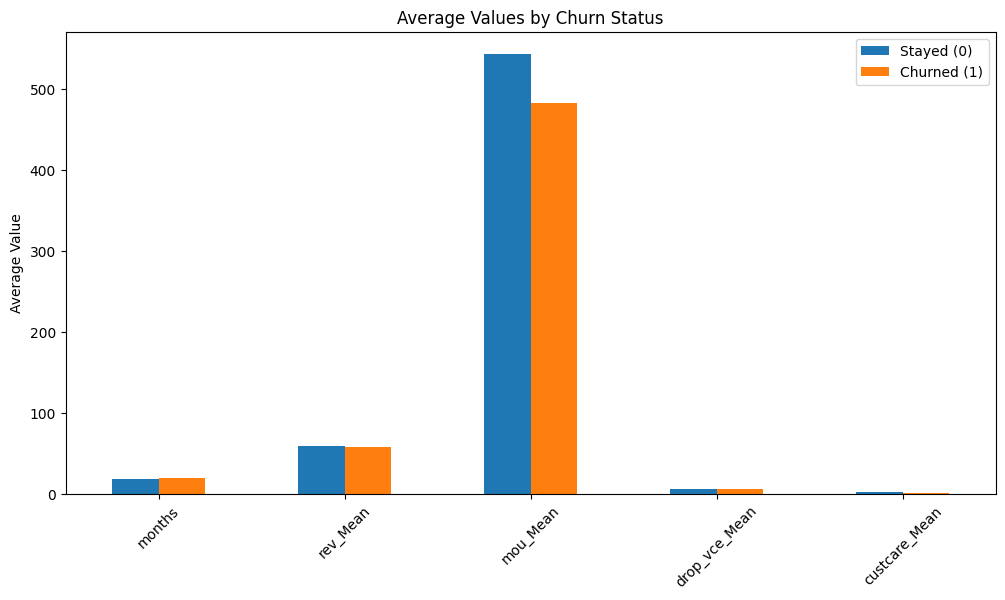

In [42]:
variables = [
    'months',
    'rev_Mean',
    'mou_Mean',
    'drop_vce_Mean',
    'custcare_Mean'
]

comparison = merged.groupby('churn')[variables].mean().T

comparison.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Average Values by Churn Status')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(['Stayed (0)', 'Churned (1)'])
plt.show()

In [40]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 98 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  object 
 3   crclscod          100000 non-null  object 
 4   asl_flag          100000 non-null  object 
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           100

In [41]:
cat_cols = merged.select_dtypes(include='object').columns
print(cat_cols)

Index(['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
       'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype',
       'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2',
       'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'],
      dtype='object')


In [44]:
cat_cols = merged.select_dtypes(include='object').columns

print(cat_cols)

le = LabelEncoder()

for col in cat_cols:
    merged[col] = le.fit_transform(merged[col].astype(str))

merged.select_dtypes(include='object').columns
merged.head(10)

Index([], dtype='object')


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,1,0,0,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,2,13,3,0,149.98999,2.0,2.0,2,0.0,0.0,0,15.0,1,3,1.0,0,4.0,2,0,0.0,9,0,0,0,0,0,1,361.0,23.9975,219.25,22.500,0.2475,0.00,0.00,0.00,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,0,21,0,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,4,3,0,0,99.98999,7.0,6.0,1,1.0,1.0,2,1.0,1,3,1.0,0,5.0,2,0,0.0,16,0,0,0,0,0,1,240.0,57.4925,482.75,37.425,0.2475,22.75,9.10,9.10,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,2,7,0,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,2,6,0,0,29.98999,2.0,1.0,2,0.0,0.0,0,7.0,1,2,2.0,0,5.0,2,0,0.0,9,0,1,0,0,0,1,1504.0,16.9900,10.25,16.990,0.0000,0.00,0.00,0.00,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,2,4,0,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,3,3,0,0,29.98999,1.0,1.0,2,0.0,0.0,2,6.0,0,2,4.0,0,6.0,2,3,0.0,14,1,0,0,0,0,1,1812.0,38.0000,7.50,38.000,0.0000,0.00,0.00,0.00,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,2,0,0,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,4,10,3,0,149.98999,6.0,4.0,2,0.0,0.0,1,5.0,0,3,1.0,0,6.0,2,14,0.0,6,0,0,0,0,0,1,434.0,55.2300,570.50,71.980,0.0000,0.00,0.00,0.00,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57
5,2,2,2,7,0,26812,40869.00000,4033.98,3932.90,40295.00,26362,83.68,857.34,560.89,1260,960,80,1187.0,853.0,78.0,4,6,0,0,129.98999,9.0,4.0,2,0.0,0.0,0,1.0,2,3,1.0,0,6.0,2,0,0.0,14,0,0,0,0,0,1,458.0,82.2750,1312.25,75.000,1.2375,0.00,0.00,0.

In [46]:
X = merged.drop('churn', axis=1)
y = merged['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]
print(y_pred)
print(y_proba)

[0 1 1 ... 0 0 1]
[0.2526264  0.71527725 0.51424867 ... 0.44383544 0.44470146 0.58640736]


Accuracy: 0.6365


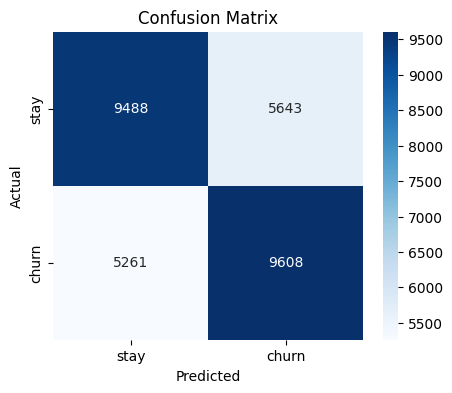

In [47]:
# Accuracy on the held-out test set
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['stay', 'churn'],
    yticklabels=['stay', 'churn']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()